# Projector Config Output Analysis
This notebook looks at the output of the configuration of a projector (in this case an example UMAP over a test.config) and looks at how to analyse is.

In [1]:
import pandas as pd


def attach_projector_params_from_grid(
    ranked_df: pd.DataFrame,
    param_grid: list[dict],
    params_col: str = "params_idx",
) -> pd.DataFrame:
    out = ranked_df.copy()
    param_dicts = out[params_col].map(lambda i: param_grid[i])
    params_expanded = pd.DataFrame(param_dicts.tolist(), index=out.index)
    return pd.concat([out, params_expanded], axis=1)


def summaries_results_for_projector(
    results_df: pd.DataFrame, 
    rank_metric: str,
    metrics: list[str],
    param_grid: list[dict],
    sort_desc: bool = True
    ) -> pd.DataFrame:

    assert rank_metric in metrics, "The rank_metric needs to be in the metrics we are measuring"

    def aggrigate_group(df, cols_group, spec):
        stats = df.groupby(cols_group, dropna=False)
        stats = stats.agg(**spec).reset_index()
        stats = stats.fillna(0.0)  # if there is one seed, seed_std will be na
        return stats

    def aggrigate_across_seeds() -> pd.DataFrame:
        cols_group = ['dataset', 'params_idx', 'n_components']
        spec = {}
        for m in metrics:
            spec[f'{m}_seed_mean'] = (m, 'mean')
            spec[f'{m}_seed_std'] = (m, 'std')
        return aggrigate_group(results_df, cols_group, spec)
    
    def aggrigate_across_dimensions(seed_stats: pd.DataFrame):
        cols_group = ['dataset', 'params_idx']
        spec = {}
        for m in metrics:
            spec[f"{m}_dim_median"] = (f"{m}_seed_mean", "median")
            spec[f"{m}_dim_std"] = (f"{m}_seed_mean", "std")
            spec[f"{m}_seed_std_mean"] = (f"{m}_seed_std", "mean")
        return aggrigate_group(seed_stats, cols_group, spec)

    def aggrigate_across_datasets(dims_stats: pd.DataFrame):
        cols_group = ['params_idx']
        spec = {}
        for m in metrics:
            spec[f"{m}_mean"] = (f"{m}_dim_median", "mean")
            spec[f"{m}_dataset_std"] = (f"{m}_dim_median", "std")
            spec[f"{m}_dim_std_mean"] = (f"{m}_dim_std", "mean")
            spec[f"{m}_seed_std_mean"] = (f"{m}_seed_std_mean", "mean")
        return aggrigate_group(dims_stats, cols_group, spec)


    seed_stats = aggrigate_across_seeds()
    dims_stats = aggrigate_across_dimensions(seed_stats)
    dataset_stats = aggrigate_across_datasets(dims_stats)

    # sort based on the ranking metric
    ranked = dataset_stats.sort_values(
        by=[f'{rank_metric}_mean', f"{rank_metric}_dataset_std"],
        ascending=[not sort_desc, True],
        kind='mergesort'
    )
    return [attach_projector_params_from_grid(res, param_grid) for res in [seed_stats, dims_stats, dataset_stats, ranked]]


In [2]:
params_grid = [
    {'n_neighbors': 5, 'min_dist': 0.25, 'metric': 'cosine'}, 
    {'n_neighbors': 5, 'min_dist': 0.5, 'metric': 'cosine'}, 
    {'n_neighbors': 30, 'min_dist': 0.25, 'metric': 'cosine'}, 
    {'n_neighbors': 30, 'min_dist': 0.5, 'metric': 'cosine'}
]

In [6]:
seed_scores = pd.read_csv('./seed_scores_test.csv')
seed_stats, dims_stats, dataset_stats, ranked  = summaries_results_for_projector(
    seed_scores,
    'mean-knn-score',
    ['mean-knn-score'],
    params_grid
)


In [10]:
seed_stats

,dataset,params_idx,n_components,mean-knn-score_seed_mean,mean-knn-score_seed_std,n_neighbors,min_dist,metric
0,kather100k_uni2,0,2,0.962462,0.002123,5,0.25,cosine
1,kather100k_uni2,0,8,0.963463,0.000708,5,0.25,cosine
2,kather100k_uni2,1,2,0.959209,0.003893,5,0.50,cosine
3,kather100k_uni2,1,8,0.963964,0.000708,5,0.50,cosine
4,kather100k_uni2,2,2,0.969219,0.001062,30,0.25,cosine
5,kather100k_uni2,2,8,0.970220,0.000354,30,0.25,cosine
6,kather100k_uni2,3,2,0.969720,0.005309,30,0.50,cosine
7,kather100k_uni2,3,8,0.972472,0.001416,30,0.50,cosine
8,spider-colorectal_uni2,0,2,0.815539,0.011811,5,0.25,cosine
9,spider-colorectal_uni2,0,8,0.830226,0.001781,5,0.25,cosine


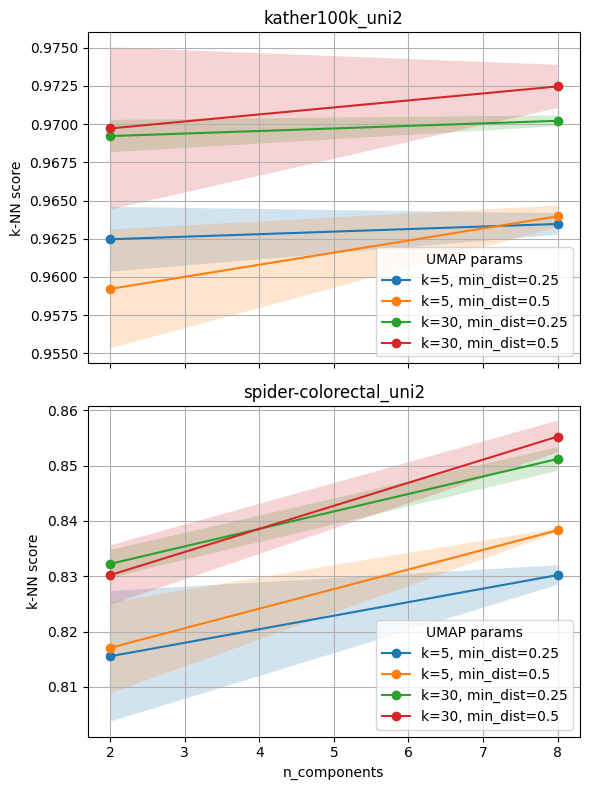

In [12]:
import matplotlib.pyplot as plt

metric_mean = "mean-knn-score_seed_mean"
metric_std = "mean-knn-score_seed_std"

datasets = seed_stats["dataset"].unique()

fig, axes = plt.subplots(
    len(datasets), 1,
    figsize=(6, 4 * len(datasets)),
    sharex=True
)

if len(datasets) == 1:
    axes = [axes]

for ax, dataset in zip(axes, datasets):
    d = seed_stats[seed_stats["dataset"] == dataset]

    # plot one curve per hyperparameter configuration
    for params_idx, g in d.groupby("params_idx"):
        g = g.sort_values("n_components")

        x = g["n_components"]
        y = g[metric_mean]
        err = g[metric_std]

        label = f"k={g['n_neighbors'].iloc[0]}, min_dist={g['min_dist'].iloc[0]}"

        ax.plot(x, y, marker="o", label=label)
        ax.fill_between(x, y - err, y + err, alpha=0.2)

    ax.set_title(dataset)
    ax.set_ylabel("k-NN score")
    ax.grid(True)
    ax.legend(title="UMAP params")

axes[-1].set_xlabel("n_components")

plt.tight_layout()
plt.show()